# 🏠 California Housing Data Analysis Project

This project focuses on analyzing housing data to understand the
factors affecting median house values using data analysis techniques

In [39]:
import pandas as pd 
df = pd.read_csv("housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 📥 Data Loading

In this section, we load the dataset and perform initial inspection.

In [40]:
df.shape

(20640, 10)

عدد الصفوف، عدد الأعمدة

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


نوع كل عمود
	عدد القيم الناقصة
	حجم الداتا

In [42]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


إحصائيات أساسية (متوسط + أكبر + أصغر…)

## missing values

In [43]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

ده يحدد الأعمدة اللي فيها Missing Values

## dealing with missing values 

In [44]:
median_bedrooms=df["total_bedrooms"].median()
df["total_bedrooms"].fillna(median_bedrooms, inplace=True)

C:\Users\RTX\AppData\Local\Temp\ipykernel_18048\2019974845.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["total_bedrooms"].fillna(median_bedrooms, inplace=True)


clean the  bedroom data the 207 line with median and why median becouse its have a lot of out liyers and need the median to deal with it the mean wont be accurate enough and the red box its a normal warning that oppears for everyone

In [45]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

here we test to see if it actually work or no and it did work the total of bedrooms becomes 0 here there is no missing 


### Outlier Detection and Treatment

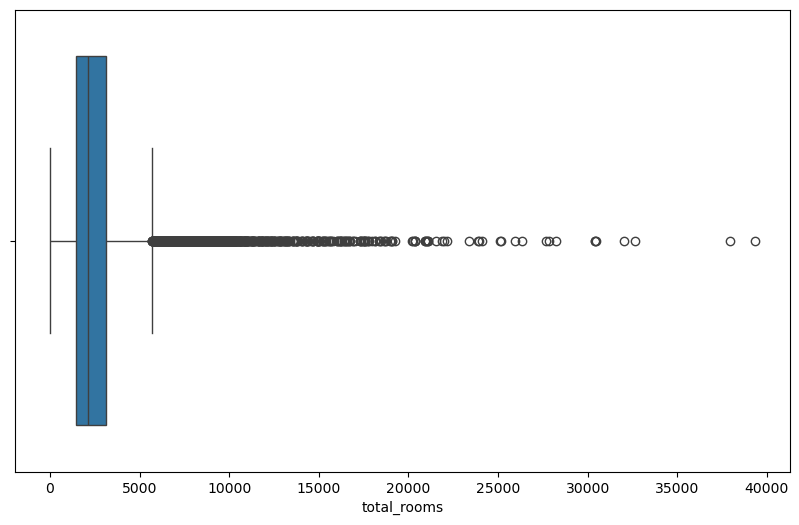

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.boxplot(x=df["total_rooms"])
plt.show()

the see the outliers and the ooutliers is the data out of the box 

## cleaning

In [47]:
Q1 = df["total_rooms"].quantile(0.25)
Q3 = df["total_rooms"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_rooms = df[(df["total_rooms"] < lower) | (df["total_rooms"] > upper)]

len(outliers_rooms)

1287

to print how many outliers in only total rooms 

In [48]:
df = df[(df["total_rooms"] >= lower) & (df["total_rooms"] <= upper)]
df.shape

(19353, 10)

here after we deleted the outliers becouse they was only 1287 and its not a big num so we choose to delete them 

this after we clean the data and now we have 19353 left and we delet 1287 its around 6.2% of the data 


Q1 = df["total_bedrooms"].quantile(0.25)
Q3 = df["total_bedrooms"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_bedrooms = df[(df["total_bedrooms"] < lower) | (df["total_bedrooms"] > upper)]

len(outliers_bedrooms)

In [49]:
df = df[(df["total_bedrooms"] >= lower) & (df["total_bedrooms"] <= upper)]
df.shape


(19353, 10)

the same but with bedrooms and we have mow 18778 line still there after cleaning the data 


In [50]:
Q1 = df["population"].quantile(0.25)
Q3 = df["population"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_population = df[(df["population"] < lower) | (df["population"] > upper)]

len(outliers_population)


604

In [51]:
df = df[(df["population"] >= lower) & (df["population"] <= upper)]
df.shape


(18749, 10)

same with population we delet 482 line of outliers

In [52]:
Q1 = df["households"].quantile(0.25)
Q3 = df["households"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_households = df[(df["households"] < lower) | (df["households"] > upper)]

len(outliers_households)


414

In [53]:
df = df[(df["households"] >= lower) & (df["households"] <= upper)]
df.shape


(18335, 10)

same with households we delete 170 line 

In [54]:
Q1 = df["median_income"].quantile(0.25)
Q3 = df["median_income"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_income = df[(df["median_income"] < lower) | (df["median_income"] > upper)]
len(outliers_income)

597

In [55]:
df = df[(df["median_income"] >= lower) & (df["median_income"] <= upper)]
df.shape

(17738, 10)

In [56]:
Q1 = df["median_house_value"].quantile(0.25)
Q3 = df["median_house_value"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_price = df[(df["median_house_value"] < lower) | (df["median_house_value"] > upper)]
len(outliers_price)

645

In [57]:
df = df[(df["median_house_value"] >= lower) & (df["median_house_value"] <= upper)]
df.shape

(17093, 10)

لأن الداتا دي أصلًا مش معلومات عن بيوت فردية
block groups” (مجمعات سكنية ضخمة)
that is why we choose to delete and we delete 18% of the data since its about realstate so its fine 


## 📊 Exploratory Data Analysis (EDA) after cleaning the data 

In this section, we explore the dataset to understand distributions 
relationships  and patterns among variables 

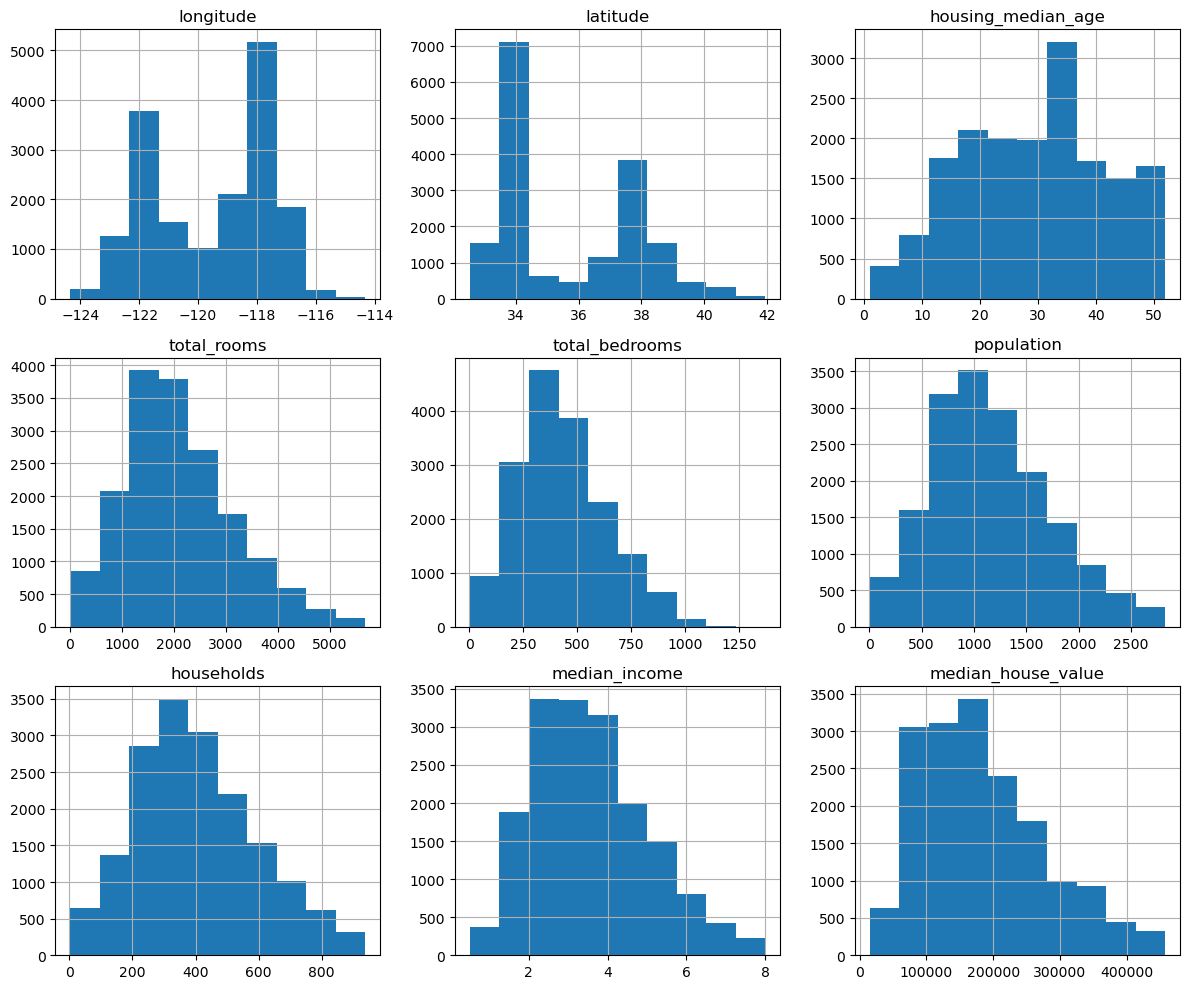

In [58]:
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

how is the data looks like after we did clean it 

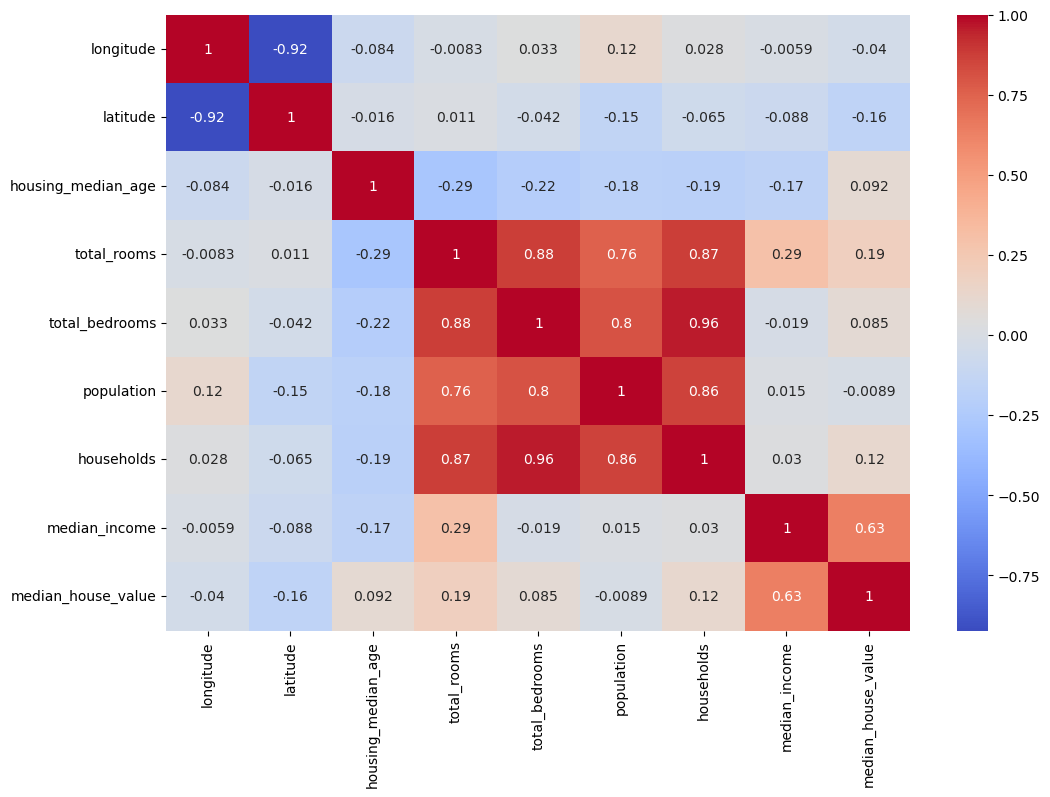

In [59]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.show()

there is a strong correlation btw the median house value and the median income 



total rooms and total bedrooms and hoseholds and population have a really strong correlation and it will help me in (PCA) becouse it was made to law the num of columes 

الدخل هو أقوى عامل بيحدد سعر البيت

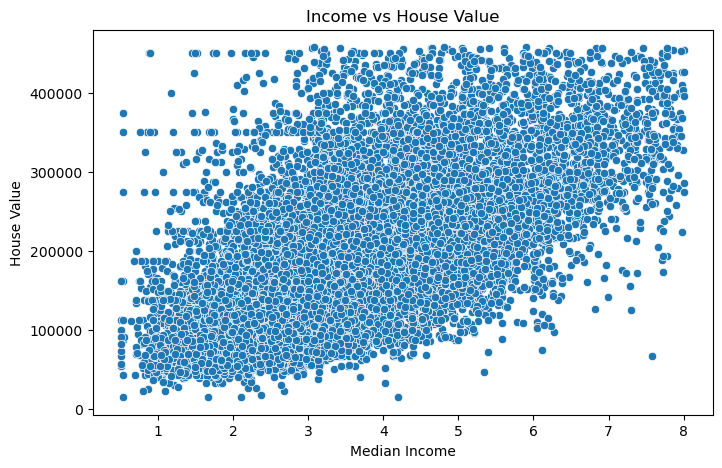

In [60]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["median_income"], y=df["median_house_value"])
plt.title("Income vs House Value")
plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.show()

to see if this true or not and its true the income is the most important thing for house value 

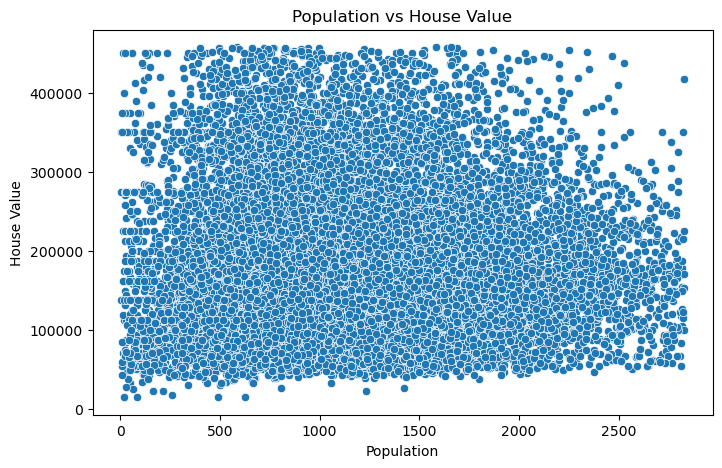

In [61]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["population"], y=df["median_house_value"])
plt.title("Population vs House Value")
plt.xlabel("Population")
plt.ylabel("House Value")
plt.show()

population dont effect the house value 

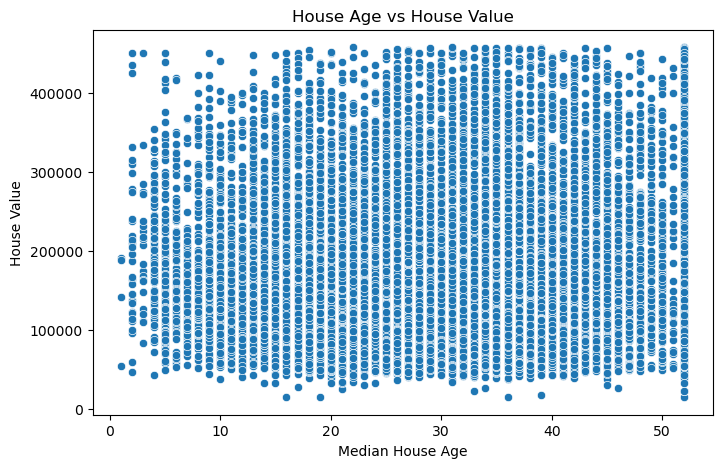

In [62]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["housing_median_age"], y=df["median_house_value"])
plt.title("House Age vs House Value")
plt.xlabel("Median House Age")
plt.ylabel("House Value")
plt.show()

house age dont effect the house value 

## 🔄 Data Encoding

Categorical features transforme into numerical values
using one-hot encoding to enable statistical analysis.

In [63]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     7335
INLAND        5777
NEAR OCEAN    2148
NEAR BAY      1828
ISLAND           5
Name: count, dtype: int64

to change the ocean_proximity to numbers so we can work on this numbers we cant work based on text 

In [64]:
df_encoded = pd.get_dummies(df, columns=["ocean_proximity"], drop_first=True)
df_encoded.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,False,False,True,False
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,False,False,True,False


وكل الموضوع أننا حولناه ل true و false او هو قريب هتكون true عن near by ocean والباقي هيكون false وهكذا

In [65]:
df_encoded.corr()["median_house_value"].sort_values(ascending=False)

median_house_value            1.000000
median_income                 0.633483
total_rooms                   0.194621
ocean_proximity_NEAR BAY      0.156032
ocean_proximity_NEAR OCEAN    0.140930
households                    0.119626
housing_median_age            0.092363
total_bedrooms                0.085266
ocean_proximity_ISLAND        0.036320
population                   -0.008871
longitude                    -0.040143
latitude                     -0.162062
ocean_proximity_INLAND       -0.514407
Name: median_house_value, dtype: float64

الرقم اللي جنب كل عمود معناه:

قد إيه العمود ده ليه علاقة بسعر البيت (median_house_value)
من -1 لحد +1
	•	+1 → علاقة قوية جدًا موجبة
	•	0 → مفيش علاقة
	•	-1 → علاقة قوية جدًا سالبة 
فا هناخد افضل ٦ بس علشان feature selection

## Feature Selection (Correlation-based)

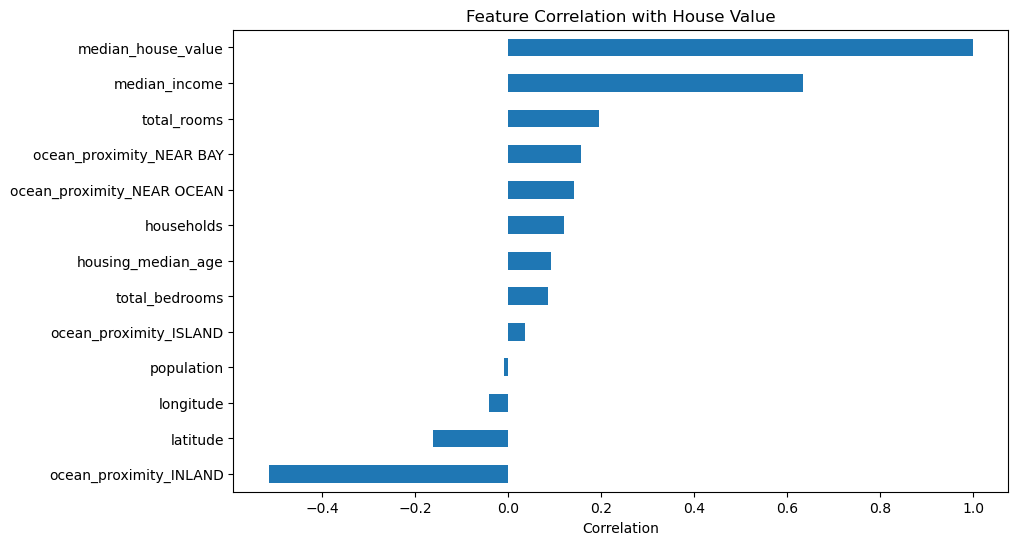

In [66]:
plt.figure(figsize=(10,6))
df_encoded.corr()["median_house_value"].sort_values().plot(kind='barh')
plt.title("Feature Correlation with House Value")
plt.xlabel("Correlation")
plt.show()

We used correlation analysis to select the most relevant features
that have the strongest relationship with the target variable
(median_house_value)

In [67]:
selected_features = df_encoded.corr()['median_house_value']
selected_features = selected_features[abs(selected_features) > 0.1].index
selected_features

Index(['latitude', 'total_rooms', 'households', 'median_income',
       'median_house_value', 'ocean_proximity_INLAND',
       'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN'],
      dtype='object')

Based on correlation values, we selected features with an absolute
correlation greater than 0.1 as the most influential features.

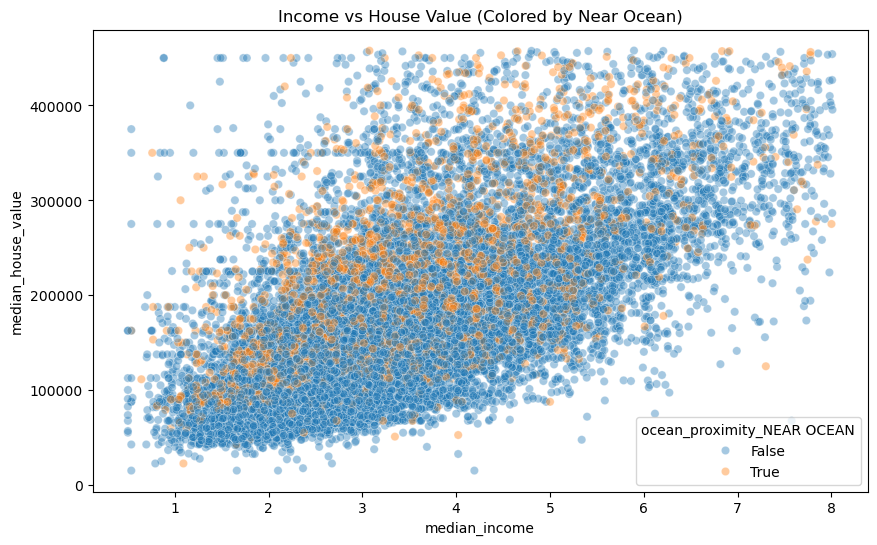

In [68]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_encoded,
    x="median_income",
    y="median_house_value",
    hue="ocean_proximity_NEAR OCEAN",
    alpha=0.4
)
plt.title("Income vs House Value (Colored by Near Ocean)")
plt.show()

بتجاوب على سؤال مهم جدًا

هل البيوت اللي جنب البحر سعرها أعلى؟ وهل الدخل بيفرق؟

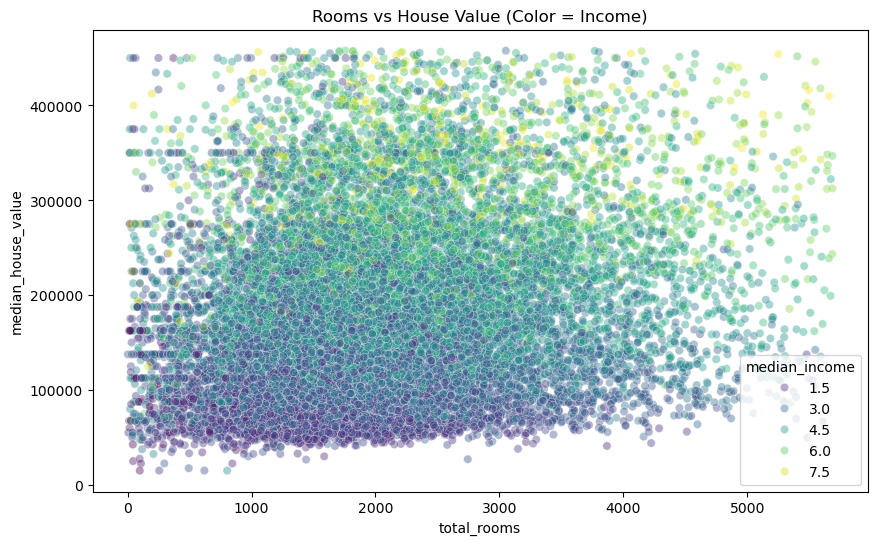

In [69]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_encoded,
    x="total_rooms",
    y="median_house_value",
    hue="median_income",
    palette="viridis",
    alpha=0.4
)
plt.title("Rooms vs House Value (Color = Income)")
plt.show()

النتيجه 
عدد الغرف لوحده مش مؤثر قوي على السعر
لإن:
	•	فيه بيوت عدد غرفها كبير وسعرها قليل
	•	وبيوت عدد غرف قليل وسعرها عالي

### 🔍 Multivariate Analysis (Pairplot)

This visualization shows the relationships between key numerical features
and the target variable (median_house_value)

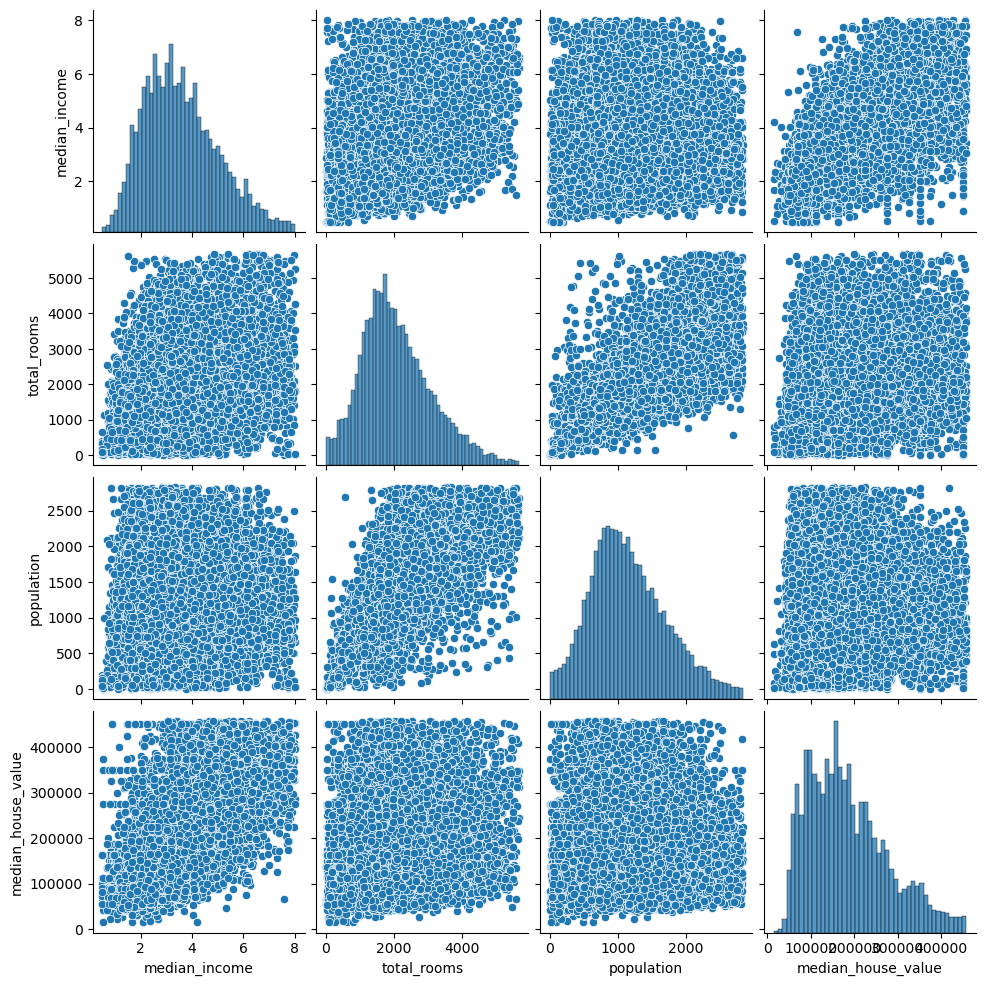

In [70]:
sns.pairplot(df_encoded[["median_income", "total_rooms", "population", "median_house_value"]])
plt.show()

1️⃣ Median Income هو أقوى مؤثر على سعر المنازل (Correlation 0.63).
2️⃣ المناطق القريبة من البحر أسعارها أعلى بوضوح.
3️⃣ عدد الغرف مش عامل رئيسي لوحده، الدخل أهم.
4️⃣ الكثافة السكانية (population) ملهاش تأثير تقريبًا على السعر.
5️⃣ العمر له تأثير بسيط جدًا.

## 📐 Probability Analysis

In this section, we calculate different probabilities to understand
the relationships between house prices, income levels, and location
(e.g., proximity to the ocean)

In [101]:
price_threshold = df['median_house_value'].median()
df['high_price'] = df['median_house_value'] > price_threshold
income_threshold = df['median_income'].median()
df['high_income'] = df['median_income'] > income_threshold

In [72]:
# 1) Probability of High Price
p_high_price = df['high_price'].mean()

# 2) Probability of High Income
p_high_income = df['high_income'].mean()

# 3) Probability of Near Ocean
p_near_ocean = (df['ocean_proximity'] == 'NEAR OCEAN').mean()

# 4) Probability of High Price GIVEN Near Ocean
p_high_price_given_near_ocean = df[df['ocean_proximity'] == 'NEAR OCEAN']['high_price'].mean()

# 5) Probability of High Income GIVEN High Price
p_high_income_given_high_price = df[df['high_price'] == True]['high_income'].mean()

# 6) Probability of BOTH High Income AND High Price
p_both = (df['high_income'] & df['high_price']).mean()

# نطبعهم
p_high_price, p_high_income, p_near_ocean, p_high_price_given_near_ocean, p_high_income_given_high_price, p_both

(np.float64(0.4997952378166501),
 np.float64(0.49956122389282165),
 np.float64(0.1256654770958872),
 np.float64(0.6308193668528864),
 np.float64(0.7375629170080767),
 np.float64(0.3686304335107939))

### Interpretation of Probability Results

- Approximately 50% of houses have prices above the median.
- Houses located near the ocean have a higher probability of being high-priced.
- High-income areas significantly increase the likelihood of higher house prices.
- The probability of both high income and high house price occurring together is relatively high.

## 🧪 Hypothesis Testing

In this section, we perform statistical hypothesis tests to examine
whether there are significant differences between groups

In [73]:
from scipy.stats import ttest_ind

# 1) T-test between Near Ocean & Inland house prices
near = df[df["ocean_proximity"]=="NEAR OCEAN"]["median_house_value"].dropna()
inland = df[df["ocean_proximity"]=="INLAND"]["median_house_value"].dropna()
t1, p1 = ttest_ind(near, inland, equal_var=False)
t1, p1

# 2) T-test between high price & low price incomes
high = df[df["high_price"]==True]["median_income"].dropna()
low  = df[df["high_price"]==False]["median_income"].dropna()
t2, p2 = ttest_ind(high, low, equal_var=False)
t2, p2

(np.float64(84.75160365988147), np.float64(0.0))

p-value=0.0




t-statistic=84.75

## Principal Component Analysis (PCA)

In this section, we apply Principal Component Analysis (PCA) to reduce the
dimensionality of the dataset while preserving as much variance as possible.
Since many numerical features are highly correlated, PCA helps simplify the
feature space, reduce noise, and improve model efficiency

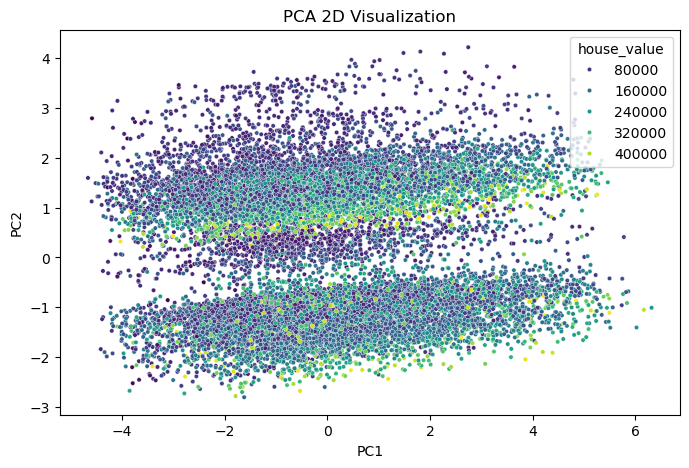

In [74]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

numeric_df = df_encoded.select_dtypes(include=["int64", "float64"])

# Scale
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame({
    "PC1": pca_result[:,0],
    "PC2": pca_result[:,1],
    "house_value": df_encoded["median_house_value"]
})

plt.figure(figsize=(8,5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="house_value", palette="viridis", s=10)
plt.title("PCA 2D Visualization")
plt.show()

يوضح هذا الرسم تمثيل البيانات باستخدام تحليل المكونات الرئيسية (PCA) بعد تقليل الأبعاد إلى بعدين فقط (PC1 و PC2).
كل نقطة في الرسم تمثل منطقة سكنية، بينما يشير اللون إلى قيمة سعر المنزل المتوسط (median_house_value).

على الرغم من أن PCA أسلوب غير إشرافي (Unsupervised) ولا يهدف إلى الفصل المباشر بين الأسعار،
إلا أنه يمكن ملاحظة اتجاه عام حيث تميل المناطق ذات أسعار المنازل الأعلى إلى التركز في اتجاهات معينة
على محوري PC1 و PC2، مما يدل على أن هذه المكونات الرئيسية تحتوي على معلومات مهمة مرتبطة بأسعار المنازل.

In [78]:
from scipy.stats import ttest_ind

# 1) T-test between Near Ocean & Inland house prices
near = df[df["ocean_proximity"]=="NEAR OCEAN"]["median_house_value"].dropna()
inland = df[df["ocean_proximity"]=="INLAND"]["median_house_value"].dropna()
t1, p1 = ttest_ind(near, inland, equal_var=False)
t1, p1

# 2) T-test between high price & low price incomes
high = df[df["high_price"]==True]["median_income"].dropna()
low  = df[df["high_price"]==False]["median_income"].dropna()
t2, p2 = ttest_ind(high, low, equal_var=False)
t2, p2

(np.float64(84.75160365988147), np.float64(0.0))

فيه فرق كبير وواضح بين أسعار البيوت اللي جنب البحر والبعيدة

والبيوت اللي قريبة من البحر أغلى بشكل واضح جدًا

## Feature Engineering

In this section, we create new meaningful features derived from existing ones.
These engineered features help better represent housing characteristics and
capture relationships that raw features alone may not fully reflect

In [81]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]

In [82]:
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]

In [83]:
df["population_per_household"] = df["population"] / df["households"]

In [84]:
df[["rooms_per_household", "bedrooms_per_room", "population_per_household"]].head()

,rooms_per_household,bedrooms_per_room,population_per_household
2,8.288136,0.129516,2.802260
3,5.817352,0.184458,2.547945
4,6.281853,0.172096,2.181467
5,4.761658,0.231774,2.139896
6,4.931907,0.192899,2.128405


add more columns

In [85]:
df["price_per_room"] = df["median_house_value"] / df["total_rooms"]

In [86]:
df["price_per_room"].head()

2    240.013633
3    267.896389
4    210.325753
5    293.471164
6    118.027613
Name: price_per_room, dtype: float64

These engineered features provide more interpretable and normalized measures,
such as per-household and per-room metrics, which can improve analysis and
model performance

In [87]:
df.shape

(17093, 16)

In [88]:
import numpy as np

## Income Categorization feature selection using lasso regression 

In this section, we categorize median income into discrete income groups to
simplify analysis and better understand income distribution patterns

In [89]:
df["income_cat"] = pd.cut(df["median_income"],
                          bins=[0., 1.5, 3.0, 4.5, 6.0, np.inf],
                          labels=[1, 2, 3, 4, 5])

In [90]:
df["income_cat"].head()

2    5
3    4
4    3
5    3
6    3
Name: income_cat, dtype: category
Categories (5, int64): [1 < 2 < 3 < 4 < 5]

بنقسم الدخل لـ 5 مستويات:
	•	1 → دخل منخفض جدًا
	•	2 → منخفض
	•	3 → متوسط
	•	4 → فوق المتوسط
	•	5 → عالي

In [91]:
df.shape

(17093, 17)

from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

numeric_df = df.select_dtypes(include=['float64', 'int64']).drop("median_house_value", axis=1)

X = numeric_df
y = df["median_house_value"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lasso = Lasso(alpha=0.1)
lasso.fit(X_scaled, y)

list(zip(X.columns, lasso.coef_))

In Lasso regression  coefficients close to zero indicate minimal impact on house
prices


Positive coefficients represent a direct effect


while negative coefficients indicate an inverse relationship Features with larger absolute
coefficients have a stronger influence on the target variable

## Feature Selection using Recursive Feature Elimination (RFE)

In this section, Recursive Feature Elimination (RFE) is applied using a linear
regression model to identify the most important features influencing house prices

In [93]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

numeric_df = df.select_dtypes(include=['float64', 'int64']).drop("median_house_value", axis=1)

X = numeric_df
y = df["median_house_value"]

model = LinearRegression()
rfe = RFE(model, n_features_to_select=5)
rfe.fit(X, y)

selected_features = X.columns[rfe.support_]
selected_features

Index(['longitude', 'latitude', 'median_income', 'bedrooms_per_room',
       'population_per_household'],
      dtype='object')

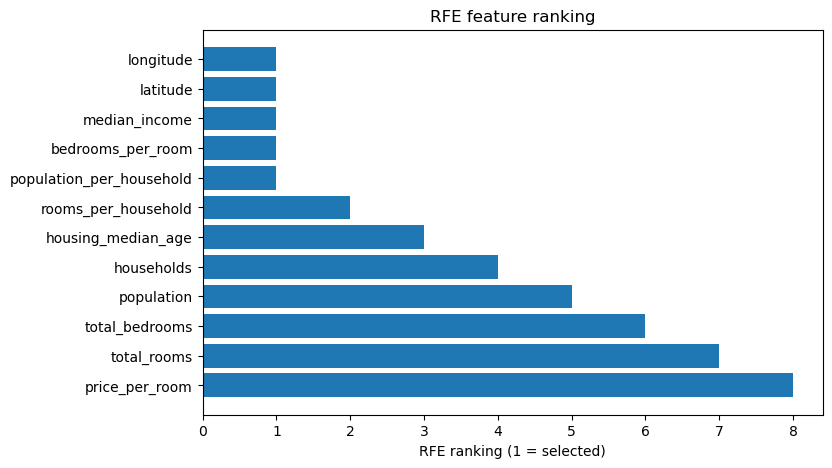

In [94]:
import matplotlib.pyplot as plt
rfe_ranks = pd.DataFrame({"feature": X.columns, "ranking": rfe.ranking_}).sort_values("ranking")
plt.figure(figsize=(8,5))
plt.barh(rfe_ranks["feature"], rfe_ranks["ranking"])
plt.gca().invert_yaxis()
plt.xlabel("RFE ranking (1 = selected)")
plt.title("RFE feature ranking")
plt.show()

## Summary and Key Insights

In [95]:
price_mean = df["median_house_value"].mean()
prob_high_price = (df["median_house_value"] > price_mean).mean()
prob_high_price

np.float64(0.4323992277540514)

the ave prices is high every 100 house have 40 house in the high price 


بناءً على البيانات، حوالي 40% من المنازل تقع في المناطق مرتفعة السعر، والأسعار هناك ليست قليلة كما قد نتوقّع ده بيشير إن توزيع البيانات مايل شوية ناحية المناطق الغالية

In [96]:
prob_high_income = (df["median_income"] > 5).mean()
prob_high_income

np.float64(0.17281928274732347)

حوالي ١٩ في الميه من الناس فقط دخلهم عالي وده منطقي لان التقرير ده في كاليفورنيا واغلب الناس مش أغنيه

In [97]:
cond_prob = df[df["ocean_proximity"]=="NEAR OCEAN"]["median_house_value"].mean() > price_mean
cond_prob

np.True_

In [98]:
prob_high_price_near_ocean = (
    df[(df["ocean_proximity"]=="NEAR OCEAN") & 
       (df["median_house_value"] > price_mean)]
).shape[0] / df[df["ocean_proximity"]=="NEAR OCEAN"].shape[0]

prob_high_price_near_ocean

0.5796089385474861

اهم نتيجه في التحليل كله واللي بتقول ان ٥٧ في الميه من البيوت اللي جنب البحر بيكون سعرها اعلي من المتوسط وده دليل ان القرب من البحر بيعلي السعر

Explained Variance Ratio: [0.2891566 0.1750628]


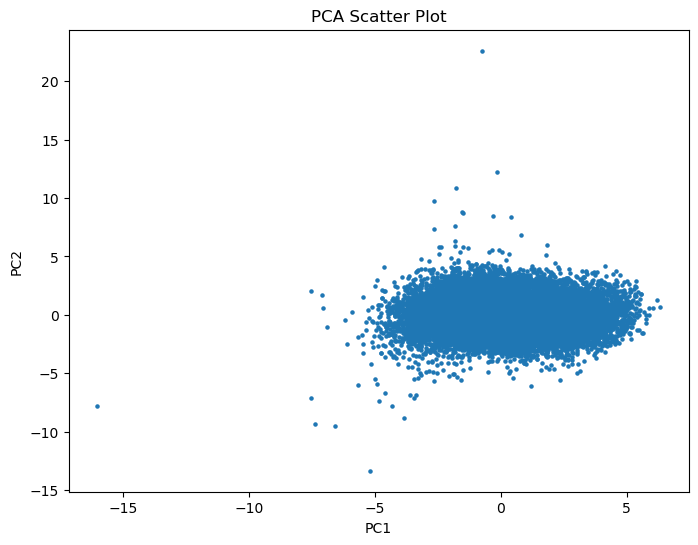

In [99]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# --- Select numeric columns only ---
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# --- Scale the data ---
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)

# --- Apply PCA ---
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# --- Add PC1 & PC2 to dataframe ---
df["PC1"] = pca_result[:, 0]
df["PC2"] = pca_result[:, 1]

# --- Explained variance ---
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

# --- Scatter plot ---
plt.figure(figsize=(8,6))
plt.scatter(df["PC1"], df["PC2"], s=5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Scatter Plot")
plt.show()

بتوضحلك شكل انتشار البيوت بعد اختصار بياناتهم وهيا مش خريطه جغرافيه هيا بس بتبين التشابه مبين البيوت والداتا بتقول ان معظم البيوت تقريبا نفس الحاجه ونفس التشابه علشان كدا في تجمع كبير
pc 1 is taken 0.28 meeans 28% of the data 
and pc 2 is taken 0.17 means 17% of the data 
so thats means its taken 48% of the data to do that test and its good percentage

In [100]:
print("Average House Price:", df["median_house_value"].mean())
print("Average Income:", df["median_income"].mean())
print("High Price Probability:", prob_high_price)
print("High Income Probability:", prob_high_income)
print("High Price Near Ocean:", prob_high_price_near_ocean)

# correlations with target
print("\nTop Correlations with House Value:")
print(df.corr(numeric_only=True)["median_house_value"].sort_values(ascending=False))

Average House Price: 185231.3283800386
Average Income: 3.572408769671795
High Price Probability: 0.4323992277540514
High Income Probability: 0.17281928274732347
High Price Near Ocean: 0.5796089385474861

Top Correlations with House Value:
median_house_value          1.000000
high_price                  0.796342
median_income               0.633483
PC2                         0.514893
high_income                 0.509544
total_rooms                 0.194621
PC1                         0.193336
households                  0.119626
housing_median_age          0.092363
rooms_per_household         0.090168
total_bedrooms              0.085266
price_per_room              0.080671
population                 -0.008871
longitude                  -0.040143
latitude                   -0.162062
population_per_household   -0.184733
bedrooms_per_room          -0.194828
Name: median_house_value, dtype: float64


من خلال التحليل ظهر إن في شوية عوامل ليها تأثير واضح على سعر البيت أهم عامل كان الدخل المتوسط للسكان، وده طلع أعلى ارتباط مع سعر البيت وده منطقي لأن المناطق اللي دخلها أعلى عادةً أسعارها بتكون أغلى

التحليل برضه وضّح إن البيوت اللي قريبة من البحر أغلبها أسعارها أعلى من المتوسط، وده بان لما لقينا نسبة كبيرة من بيوت NEAR OCEAN أسعارها فوق المتوسط

بالنسبة لباقي الأعمدة، لقينا إن عدد الغرف له علاقة موجبة بالسعر، يعني البيوت الأكبر سعرها أعلى، لكن العلاقة مش قوية جدًا

السن المتوسط للمباني كان ليه تأثير بسيط، والظاهر إن في مناطق البيوت الأديمة شوية بيكون سعرها أعلى

لاحظت كمان إن الأماكن اللي فيها عدد كبير من السكان بالنسبة لعدد البيوت بيكون سعرها أقل وده طبيعي لأنها بتكون مناطق أقل ثراء أو ازدحامها أعلى

أما بالنسبة للموقع، الاتجاهات (longitude و latitude) كان ليها ارتباط سلبي بسيط مع السعر وده معناه إن المناطق الأبعد من الساحل بتكون أسعارها أقل

في الآخر العوامل اللي طالعة إنها الأكثر تأثيرًا كانت
(الدخل)
الموقع القريب من البحر
عدد الغرف 
وعدد الأشخاص لكل بيت